# Project REXIA

# Image data

## Imports et préliminaires

In [43]:
import tensorflow
from tensorflow.keras.applications import inception_v3

from keras import preprocessing
import keras.applications
from keras.preprocessing import image
from keras.applications.imagenet_utils import decode_predictions
from skimage.io import imread
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import lime
from lime import lime_image
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
#import data
DATA_PATH = r"C:\Users\Asturiel\Documents\Cours\CentraleSupelec_COURS\Third_Year\REXIA\projet-rexia\rexia-responsible-explainable-ai-project\data\image_data"

In [45]:
df_attributes = pd.read_csv(str(DATA_PATH +  r"\list_attr_celeba.csv"))
df_bbox = pd.read_csv(str(DATA_PATH + r"\list_bbox_celeba.csv"))
df_eval_partitions = pd.read_csv(str(DATA_PATH + r"\list_eval_partition.csv"))
df_landmarks = pd.read_csv(str(DATA_PATH + r"\list_landmarks_align_celeba.csv"))

## Analyse du jeu de données

### Analyse descriptive

Data Files

- img_align_celeba.zip: All the face images, cropped and aligned 
list_eval_partition.csv: Recommended partitioning of images into training, validation, testing sets. Images 1-162770 are training, 162771-182637 are validation, 182638-202599 are testing 
- list_bbox_celeba.csv: Bounding box information for each image. "x_1" and "y_1" represent the upper left point coordinate of bounding box. "width" and "height" represent the width and height of bounding box
- list_landmarks_align_celeba.csv: Image landmarks and their respective coordinates. There are 5 landmarks: left eye, right eye, nose, left mouth, right mouth 
- list_attr_celeba.csv: Attribute labels for each image. There are 40 attributes. "1" represents positive while "-1" represents negative

In [46]:
print(df_attributes.shape)  # 202599 pictures and 41 attributes (including the image name) 
display(df_attributes.head())              
print(f"List of attributes : {df_attributes.columns.tolist()}")            
print("----------------------------------")
print("Number of positives per attribute:") 
display((df_attributes == 1).sum())
print("----------------------------------")
print(f"Average number of positives accrosss all attributes: {(df_attributes == 1).mean() } ")

(202599, 41)


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


List of attributes : ['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']
----------------------------------
Number of positives per attribute:


image_id                    0
5_o_Clock_Shadow        22516
Arched_Eyebrows         54090
Attractive             103833
Bags_Under_Eyes         41446
Bald                     4547
Bangs                   30709
Big_Lips                48785
Big_Nose                47516
Black_Hair              48472
Blond_Hair              29983
Blurry                  10312
Brown_Hair              41572
Bushy_Eyebrows          28803
Chubby                  11663
Double_Chin              9459
Eyeglasses              13193
Goatee                  12716
Gray_Hair                8499
Heavy_Makeup            78390
High_Cheekbones         92189
Male                    84434
Mouth_Slightly_Open     97942
Mustache                 8417
Narrow_Eyes             23329
No_Beard               169158
Oval_Face               57567
Pale_Skin                8701
Pointy_Nose             56210
Receding_Hairline       16163
Rosy_Cheeks             13315
Sideburns               11449
Smiling                 97669
Straight_H

----------------------------------
Average number of positives accrosss all attributes: image_id               0.000000
5_o_Clock_Shadow       0.111136
Arched_Eyebrows        0.266981
Attractive             0.512505
Bags_Under_Eyes        0.204572
Bald                   0.022443
Bangs                  0.151575
Big_Lips               0.240796
Big_Nose               0.234532
Black_Hair             0.239251
Blond_Hair             0.147992
Blurry                 0.050899
Brown_Hair             0.205194
Bushy_Eyebrows         0.142168
Chubby                 0.057567
Double_Chin            0.046688
Eyeglasses             0.065119
Goatee                 0.062764
Gray_Hair              0.041950
Heavy_Makeup           0.386922
High_Cheekbones        0.455032
Male                   0.416754
Mouth_Slightly_Open    0.483428
Mustache               0.041545
Narrow_Eyes            0.115149
No_Beard               0.834940
Oval_Face              0.284143
Pale_Skin              0.042947
Pointy_Nose     

<Axes: ylabel='None'>

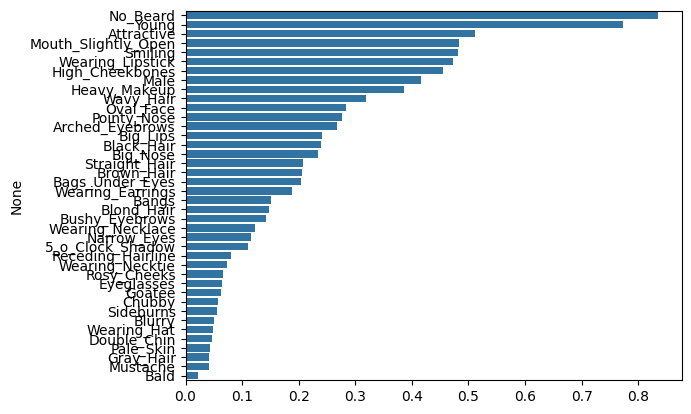

In [47]:
positive_rate = (df_attributes.drop('image_id', axis=1) == 1).mean().sort_values(ascending=False)
sns.barplot(x=positive_rate.values, y=positive_rate.index)

In [48]:
attr_cols = df_attributes.columns[1:]  # all columns except 'image_id'
df_eval_partitions['partition'].value_counts()    # 0=train, 1=val, 2=test
# puis merge avec les attributs pour vérifier que la distribution est homogène
merged = df_attributes.merge(df_eval_partitions, on='image_id')
merged.groupby('partition')[attr_cols].mean()

,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
partition,,,,,,,,,,,,,,,,,,,,,
0,-0.776654,-0.468231,0.027253,-0.591079,-0.954377,-0.696689,-0.518179,-0.528894,-0.521951,-0.701825,...,-0.887498,-0.040609,-0.582884,-0.361283,-0.626934,-0.901223,-0.060797,-0.757154,-0.853904,0.557879
1,-0.763930,-0.483163,0.040117,-0.585141,-0.958625,-0.706549,-0.693562,-0.502391,-0.582826,-0.692354,...,-0.862385,-0.033372,-0.588765,-0.446821,-0.618563,-0.905371,-0.108069,-0.758796,-0.854734,0.493129
2,-0.800220,-0.431119,-0.008316,-0.594730,-0.957619,-0.688508,-0.345957,-0.575994,-0.456768,-0.733494,...,-0.907224,0.000601,-0.580202,-0.271917,-0.586715,-0.915940,0.043783,-0.724176,-0.859834,0.514277


### Analyse des corrélations

<Axes: >

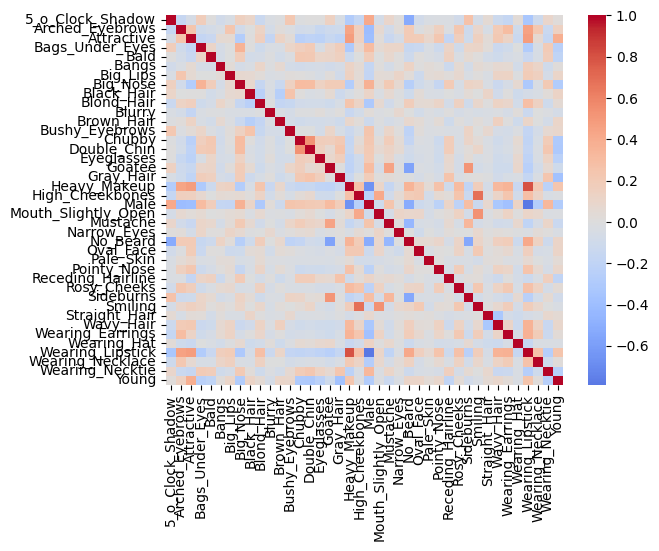

In [49]:
df_binary = (df_attributes[attr_cols] == 1).astype(int)
corr_matrix = df_binary.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True)

In [50]:
# Extraire le triangle supérieur sans la diagonale
corr_pairs = (corr_matrix
              .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
              .stack()
              .sort_values(ascending=False))

corr_pairs.head(15)   # plus corrélées positivement
corr_pairs.tail(15)   # plus corrélées négativement

Double_Chin       Young              -0.309809
Straight_Hair     Wavy_Hair          -0.321452
Male              Wavy_Hair          -0.323983
5_o_Clock_Shadow  Wearing_Lipstick   -0.333921
Gray_Hair         Young              -0.364466
Male              Wearing_Earrings   -0.373469
Attractive        Male               -0.394451
Arched_Eyebrows   Male               -0.408016
Mustache          No_Beard           -0.452595
Male              No_Beard           -0.522243
5_o_Clock_Shadow  No_Beard           -0.526946
No_Beard          Sideburns          -0.543061
Goatee            No_Beard           -0.570071
Heavy_Makeup      Male               -0.666724
Male              Wearing_Lipstick   -0.789435
dtype: float64

#### Corrélations artificielles

Deux variables sont artificiellement corrélées quand leur forte corrélation statistique entre deux variables qui n'ont pas de lien causal directs mais résulte d'un troisième facteur.

**Wearing_Lipstick <-> Male** : forte corrélation négative, mais causée par le genre comme variable confondante - ce n'est pas que le rouge à lèvres cause d'être femme, c'est que les deux co-occurrent dans les données de collecte.

**Heavy_Makeup <-> Attractive** : corrélées positivement, mais le lien est biaisé par les standards de beauté présents dans les annotations humaines.

<Axes: >

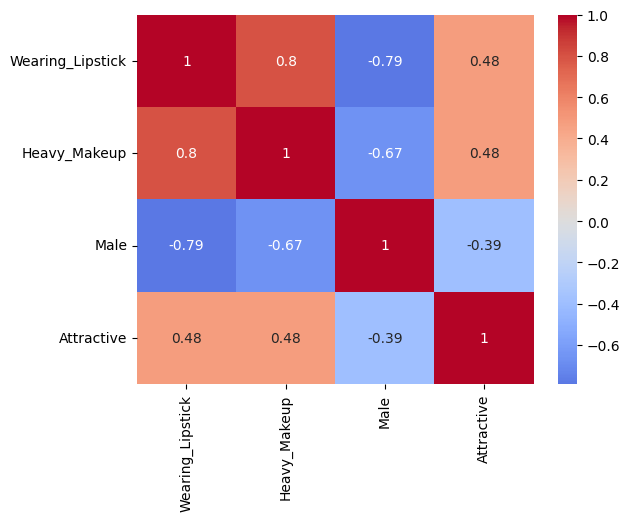

In [ ]:
# tableau croisé
pd.crosstab(df_binary['Wearing_Lipstick'], df_binary['Male'], normalize='index')
# ou un heatmap de la sous-matrice
sns.heatmap(df_binary[['Wearing_Lipstick', 'Heavy_Makeup', 'Male', 'Attractive']].corr(),
            annot=True, cmap='coolwarm', center=0)

### Identification de variables sensibles

La justification de la sensibilité d'une variable repose sur trois critères : **caractéristique protégée** (genre, couleur de peau, âge = protégés par la loi en France/UE), **risque de discrimination** si utilisée dans un modèle, et **déséquilibre de représentation**. Par exemple Pale_Skin n'est pas directement un attribut légalement protégé mais il est un proxy de l'origine ethnique - ce qui le rend sensible.

In [ ]:
sensitive = ['Male', 'Pale_Skin', 'Young']
(df_binary[sensitive] == 1).mean()   # taux de présence dans le dataset

Male          0.416754
Pale_Skin     0.042947
Young         0.773617
Black_Hair    0.239251
Blond_Hair    0.147992
dtype: float64

### Analyse de disparité

Pale_Skin,0,1
Male,,
0,0.550447,0.032799
1,0.406606,0.010148


<Axes: >

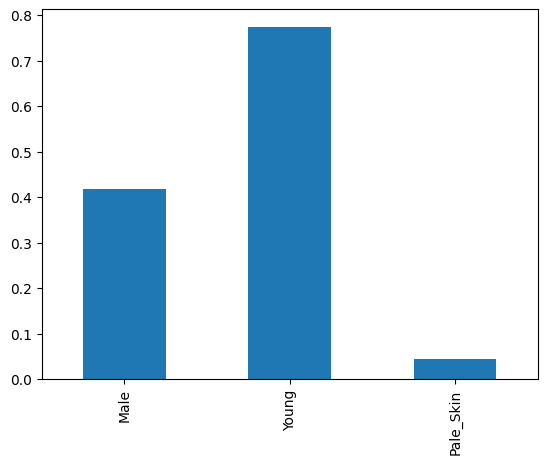

In [56]:
# Distribution de Male
df_binary['Male'].value_counts(normalize=True)

# Croisement de deux attributs sensibles
display(pd.crosstab(df_binary['Male'], df_binary['Pale_Skin'], normalize='all'))

# Pour visualiser plusieurs groupes simultanément
group_cols = ['Male', 'Young', 'Pale_Skin']
df_binary[group_cols].mean().plot(kind='bar')

biais de représentativité : 55% de femmes à la peau pâle.

In [57]:
# Combinaisons rares
df_binary.groupby(['Male', 'Pale_Skin', 'Young']).size().sort_values()

Male  Pale_Skin  Young
1     1          0          483
0     1          0          739
1     1          1         1573
0     1          1         5906
      0          0        14139
1     0          0        30504
                 1        51874
0     0          1        97381
dtype: int64

### Analyse de la fairness

In [52]:
def fairness_metrics(df, sensitive_attr, target_attr):
    groups = df.groupby(sensitive_attr)[target_attr].mean()
    # groups[1]  = P(Y=1 | S=1)
    # groups[0]  = P(Y=1 | S=-1)  (on a converti -1 → 0 avant)
    
    p_s1 = groups[1]
    p_s0 = groups[0]
    
    demographic_parity = abs(p_s1 - p_s0)
    disparate_impact   = p_s1 / p_s0 if p_s0 > 0 else np.nan
    
    return {'demographic_parity': demographic_parity,
            'disparate_impact': disparate_impact}

## Apprentissage automatique

## Explications post-hoc

> Lime Shapley

In [53]:
# Création de l'explainer LIME
limeExplainer = lime_image.LimeImageExplainer(
        
)

explanation = limeExplainer.explain_instance(
    image = imgs[0],
    classifier_fn=model.predict,
    top_labels=4,
    num_samples= 5)         

NameError: name 'imgs' is not defined